# Imports

In [1]:
import sys
import imp
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import spearmanr,pearsonr,ttest_1samp, ttest_ind
import pickle
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
sys.path.append('../data_processing_code/')
sys.path.append('.')

import get_data
imp.reload(get_data)
from get_data import get_data, get_data_online

import plotting
imp.reload(plotting)
from plotting import *


In [3]:
def scale_fun(X, axis=0, with_mean=True, with_std=True, copy=True):
    X = X.copy()
    X = np.asarray(X)

    if with_mean:
        mean_ = np.nanmean(X, axis)
    if with_std:
        scale_ = np.nanstd(X, axis)
    # Xr is a view on the original array that enables easy use of
    # broadcasting on the axis in which we are interested in
    Xr = np.rollaxis(X, axis)
    if with_mean:
        Xr -= mean_
        mean_1 = np.nanmean(Xr, axis=0)
        # Verify that mean_1 is 'close to zero'. If X contains very
        # large values, mean_1 can also be very large, due to a lack of
        # precision of mean_. In this case, a pre-scaling of the
        # concerned feature is efficient, for instance by its mean or
        # maximum.
        if not np.allclose(mean_1, 0):
            warnings.warn("Numerical issues were encountered "
                          "when centering the data "
                          "and might not be solved. Dataset may "
                          "contain too large values. You may need "
                          "to prescale your features.")
            Xr -= mean_1
    if with_std:
        scale_ = scale_ #_handle_zeros_in_scale(scale_, copy=False)
        Xr /= scale_
        if with_mean:
            mean_2 = np.nanmean(Xr, axis=0)
            # If mean_2 is not 'close to zero', it comes from the fact that
            # scale_ is very small so that mean_2 = mean_1/scale_ > 0, even
            # if mean_1 was close to zero. The problem is thus essentially
            # due to the lack of precision of mean_. A solution is then to
            # subtract the mean again:
            if not np.allclose(mean_2, 0):
                warnings.warn("Numerical issues were encountered "
                              "when scaling the data "
                              "and might not be solved. The standard "
                              "deviation of the data is probably "
                              "very close to 0. ")
                Xr -= mean_2
    return X

In [4]:
def convert_diagnosis_to_color(diag):
    color=[]
    for d in diag:
        if d=='control_mfmri':
            color.append(sns.color_palette()[0])
        elif d=='control_cdm':
            color.append(sns.color_palette()[1])
        elif d=='MDD':
            color.append(sns.color_palette()[2])
        elif d=='GAD':
            color.append(sns.color_palette()[6])
        elif d=='amt':
            color.append(sns.color_palette()[4])
    return(color)

# Load Shared Data

## Load Data

In [5]:
dftmp = pd.read_csv('../data/participant_table_exp1.csv')
data = get_data(dftmp)

pain task excluded:12
rew task excluded:9
has both: 71
pain only:6
rew only:9
subj X task:157
subjs:86
(180, 157)
(180, 157)
(180, 157)
(180, 157)


## Load Online Data

In [6]:
dftmp = pd.read_csv('../data/participant_table_exp2.csv')
data_online = get_data_online(dftmp)

subj X task:294
subjs:147
(180, 294)
(180, 294)
(180, 294)
(180, 294)


# Specs

In [7]:
plt.rcParams.update({'font.size': 11})
plt.rcParams.update({'font.family': 'normal'})

# x,y label size
labelsize =10
ticklabelsize=8
legendsize=8

# Supplemental Figures with Alternative Models

## Main Model

In [143]:
# load the model 
model_name = 'model_flex_both_Bi3itemCDM_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_4_27_2000_3all__cdm.pkl'
with open('../fitting_behavioral_model_exp1/model_fits/'+model_name, "rb" ) as buff:
    model_output = pickle.load(buff)
trace_main=model_output['trace']
ppc_main=model_output['ppc']
model_main=model_output['model']

## G + MASQADresidG + PSWQresidG

In [144]:
# load the model 
model_name = 'model_flex_both_G_ADrG_PSWQrG_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_10_2_2000_3all__cdm.pkl'
with open('../fitting_behavioral_model_exp1/model_fits/'+model_name, "rb" ) as buff:
    model_output = pickle.load(buff)
trace=model_output['trace']
ppc=model_output['ppc']
model=model_output['model']

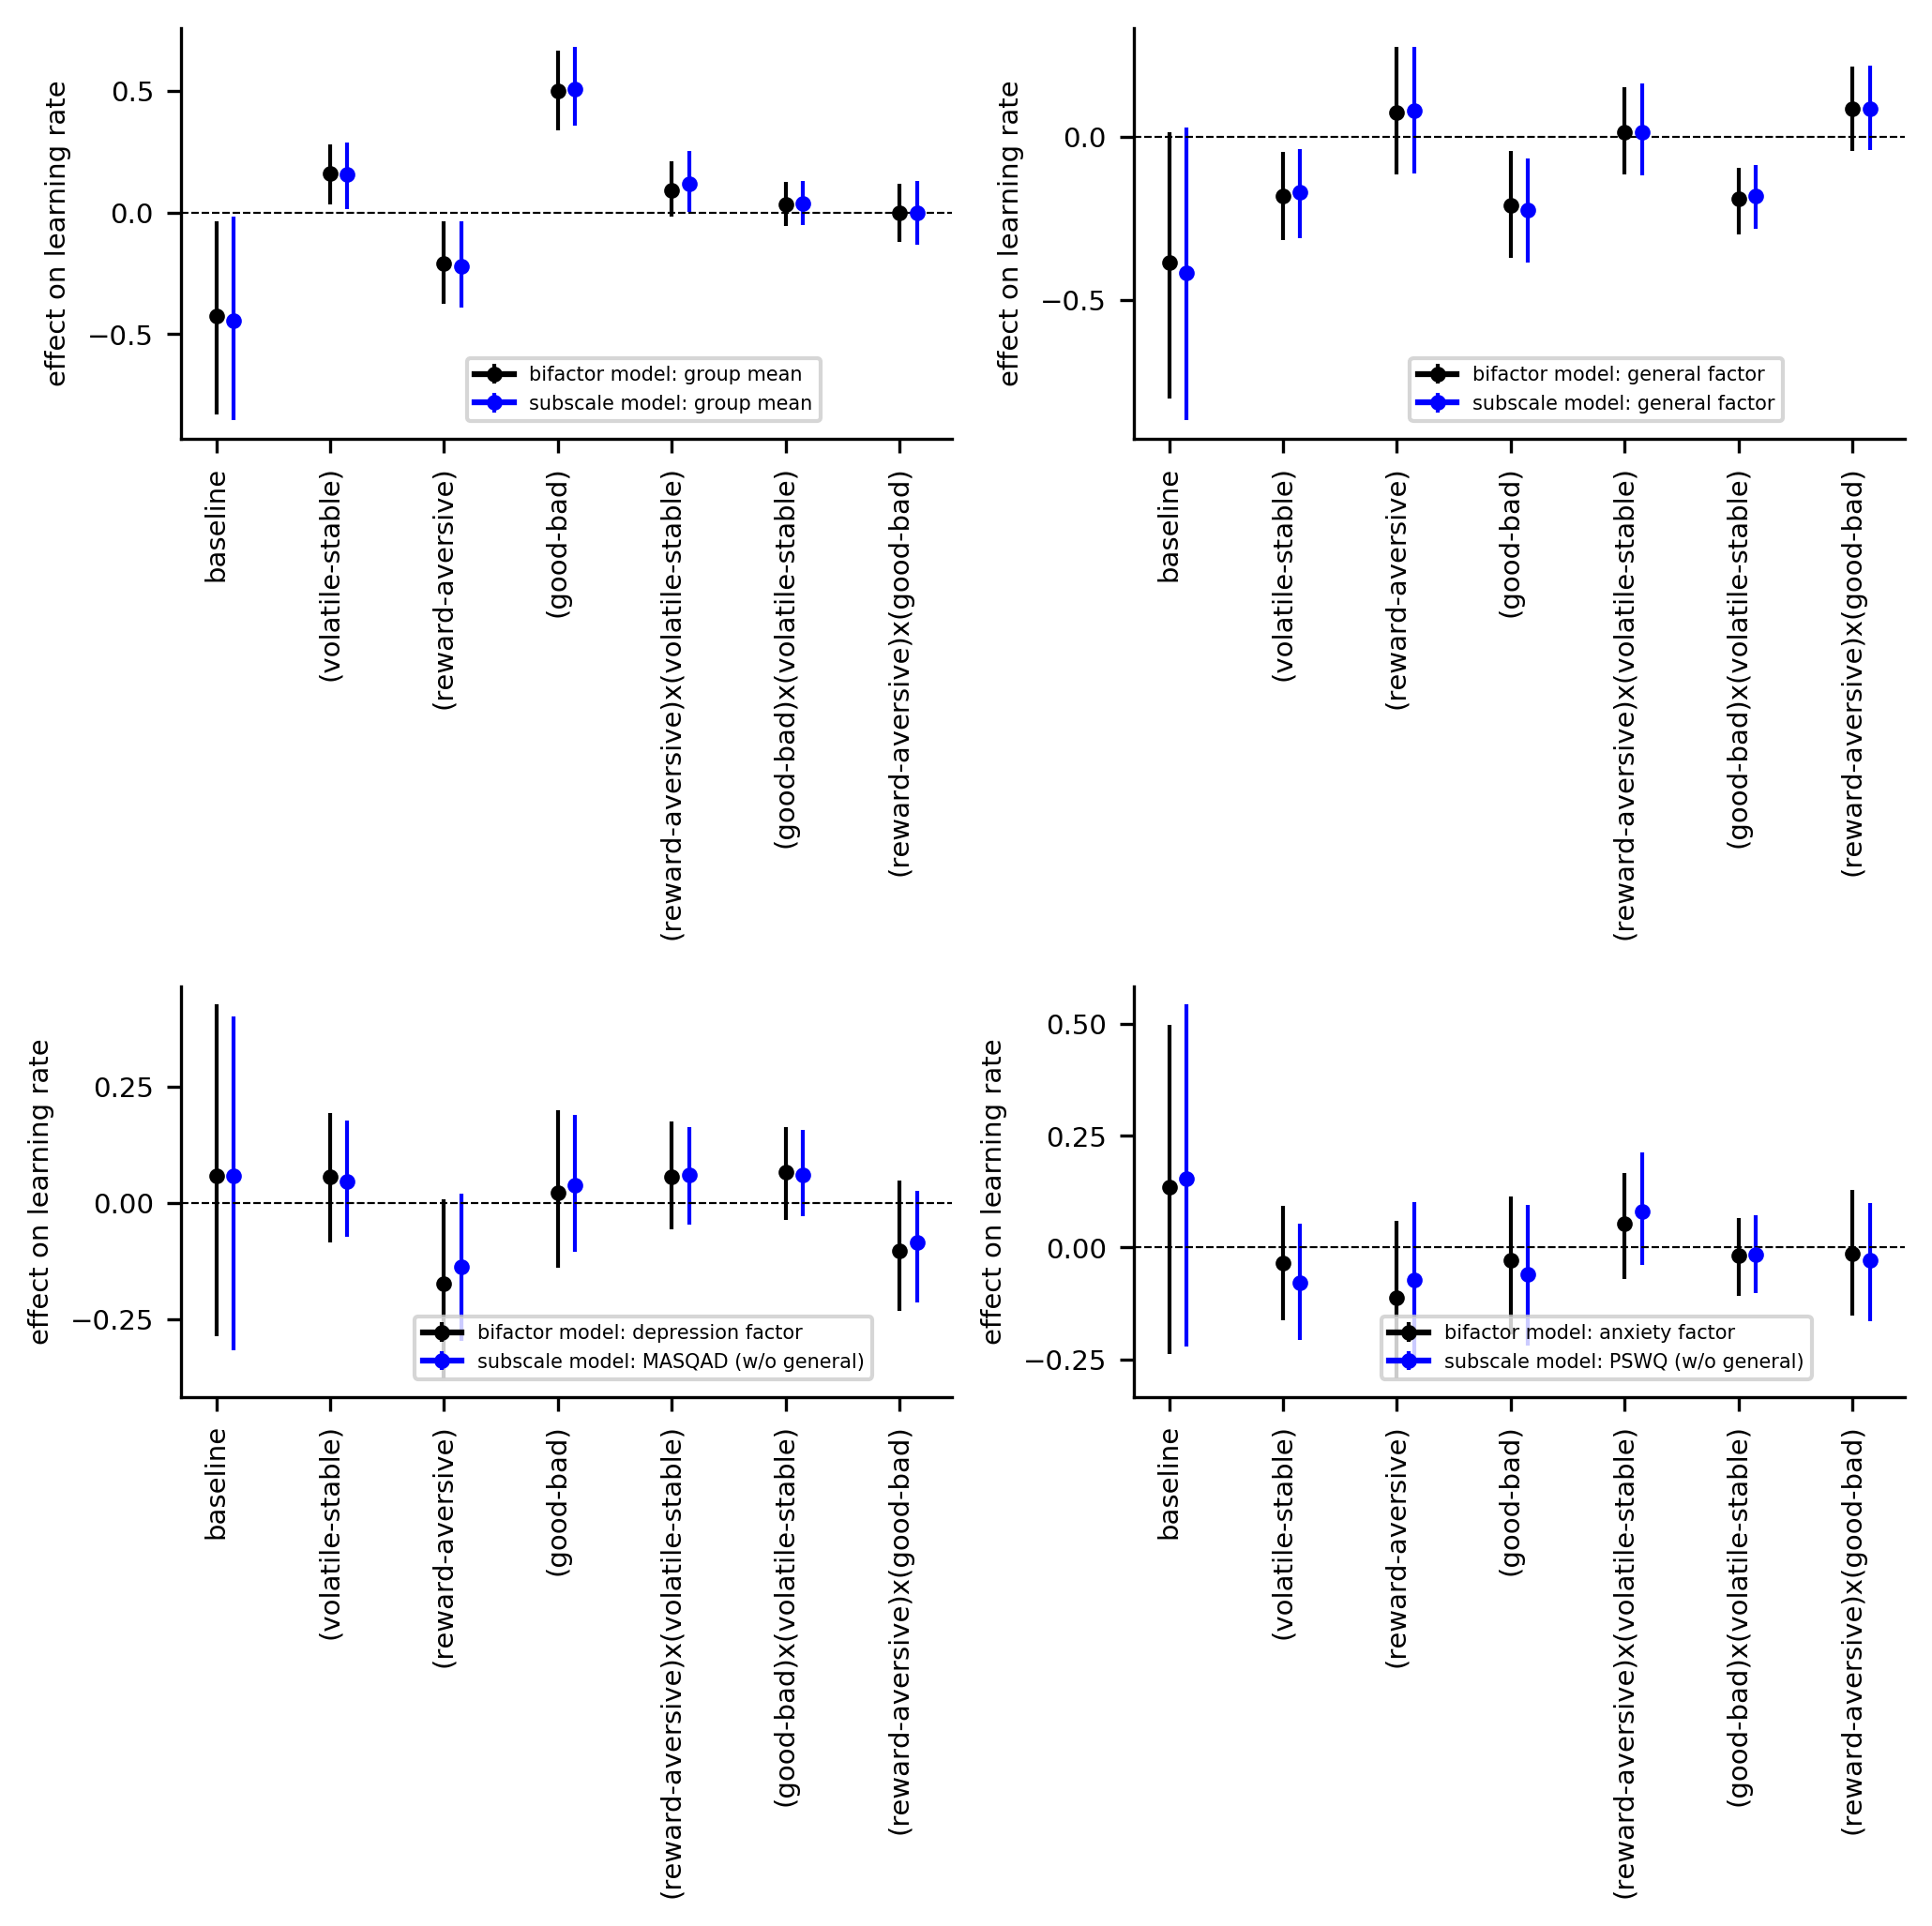

In [262]:

fig,axes  = plt.subplots(2,2,figsize=(7,7),dpi=300)
axes = axes.flatten()

for ax,gparam,gparam_name,gparam_name2 in zip(axes,
                                 ['u','u_PC1','u_PC2','u_PC3'],
                                 ['group mean','general factor','depression factor','anxiety factor'],
                                 ['group mean','general factor','MASQAD (w/o general)','PSWQ (w/o general)']):

    
    plot_param_posterior_errorbars_onesubplot(trace=trace_main, # data
                        params=model_main.params, # model parameter names 
                        gp=gparam, # group parameter 
                        param = 'lr', # readable name 
                        online=False, # different name replacing
                        scale='logit',
                        flipstab=True,
                        mode=False, # use posteriod mode or mean
                        offset=0,
                        ax=ax,# plot characteristics 
                        color='k', 
                        legend=True,
                        title=None,
                        legendlabel='bifactor model: '+gparam_name,
                        ylabel='effect on learning rate',
                        ylabelsize =7,
                        xlabelsize = 7,
                        titlesize = 7,
                        xticklabelsize=7,
                        yticklabelsize=7,
                        legendsize=5,
                        s_bar=3,
                        elinewidth=1,
                        legend_anchor=[0.6,0.02],
                        name_replace=name_replace_nounderscores)
    
    plot_param_posterior_errorbars_onesubplot(trace=trace, # data
                params=model.params, # model parameter names 
                gp=gparam, # group parameter 
                param = 'lr', # readable name 
                online=False, # different name replacing
                scale='logit',
                flipstab=True,
                mode=False, # use posteriod mode or mean
                offset=0.15,
                ax=ax,# plot characteristics 
                color='b', 
                legend=True,
                title=None,
                legendlabel='subscale model: '+gparam_name2,
                ylabel='effect on learning rate',
                ylabelsize =7,
                xlabelsize = 7,
                titlesize = 7,
                xticklabelsize=7,
                yticklabelsize=7,
                legendsize=5,
                s_bar=3,
                elinewidth=1,
                legend_anchor=[0.6,0.02],
                name_replace=name_replace_nounderscores)
    
plt.tight_layout()

plt.savefig('../figures/supp_G_ADrG_PSWQrG_3factor_model_learning_rates_group.png',bbox_inches='tight',dpi=500)

## G + MASQADresidG + MASQAA

In [263]:
# load the model 
model_name = 'model_flex_both_G_ADrG_AArG_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_10_2_2000_3all__cdm.pkl'
with open('../fitting_behavioral_model_exp1/model_fits/'+model_name, "rb" ) as buff:
    model_output = pickle.load(buff)
trace=model_output['trace']
ppc=model_output['ppc']
model=model_output['model']

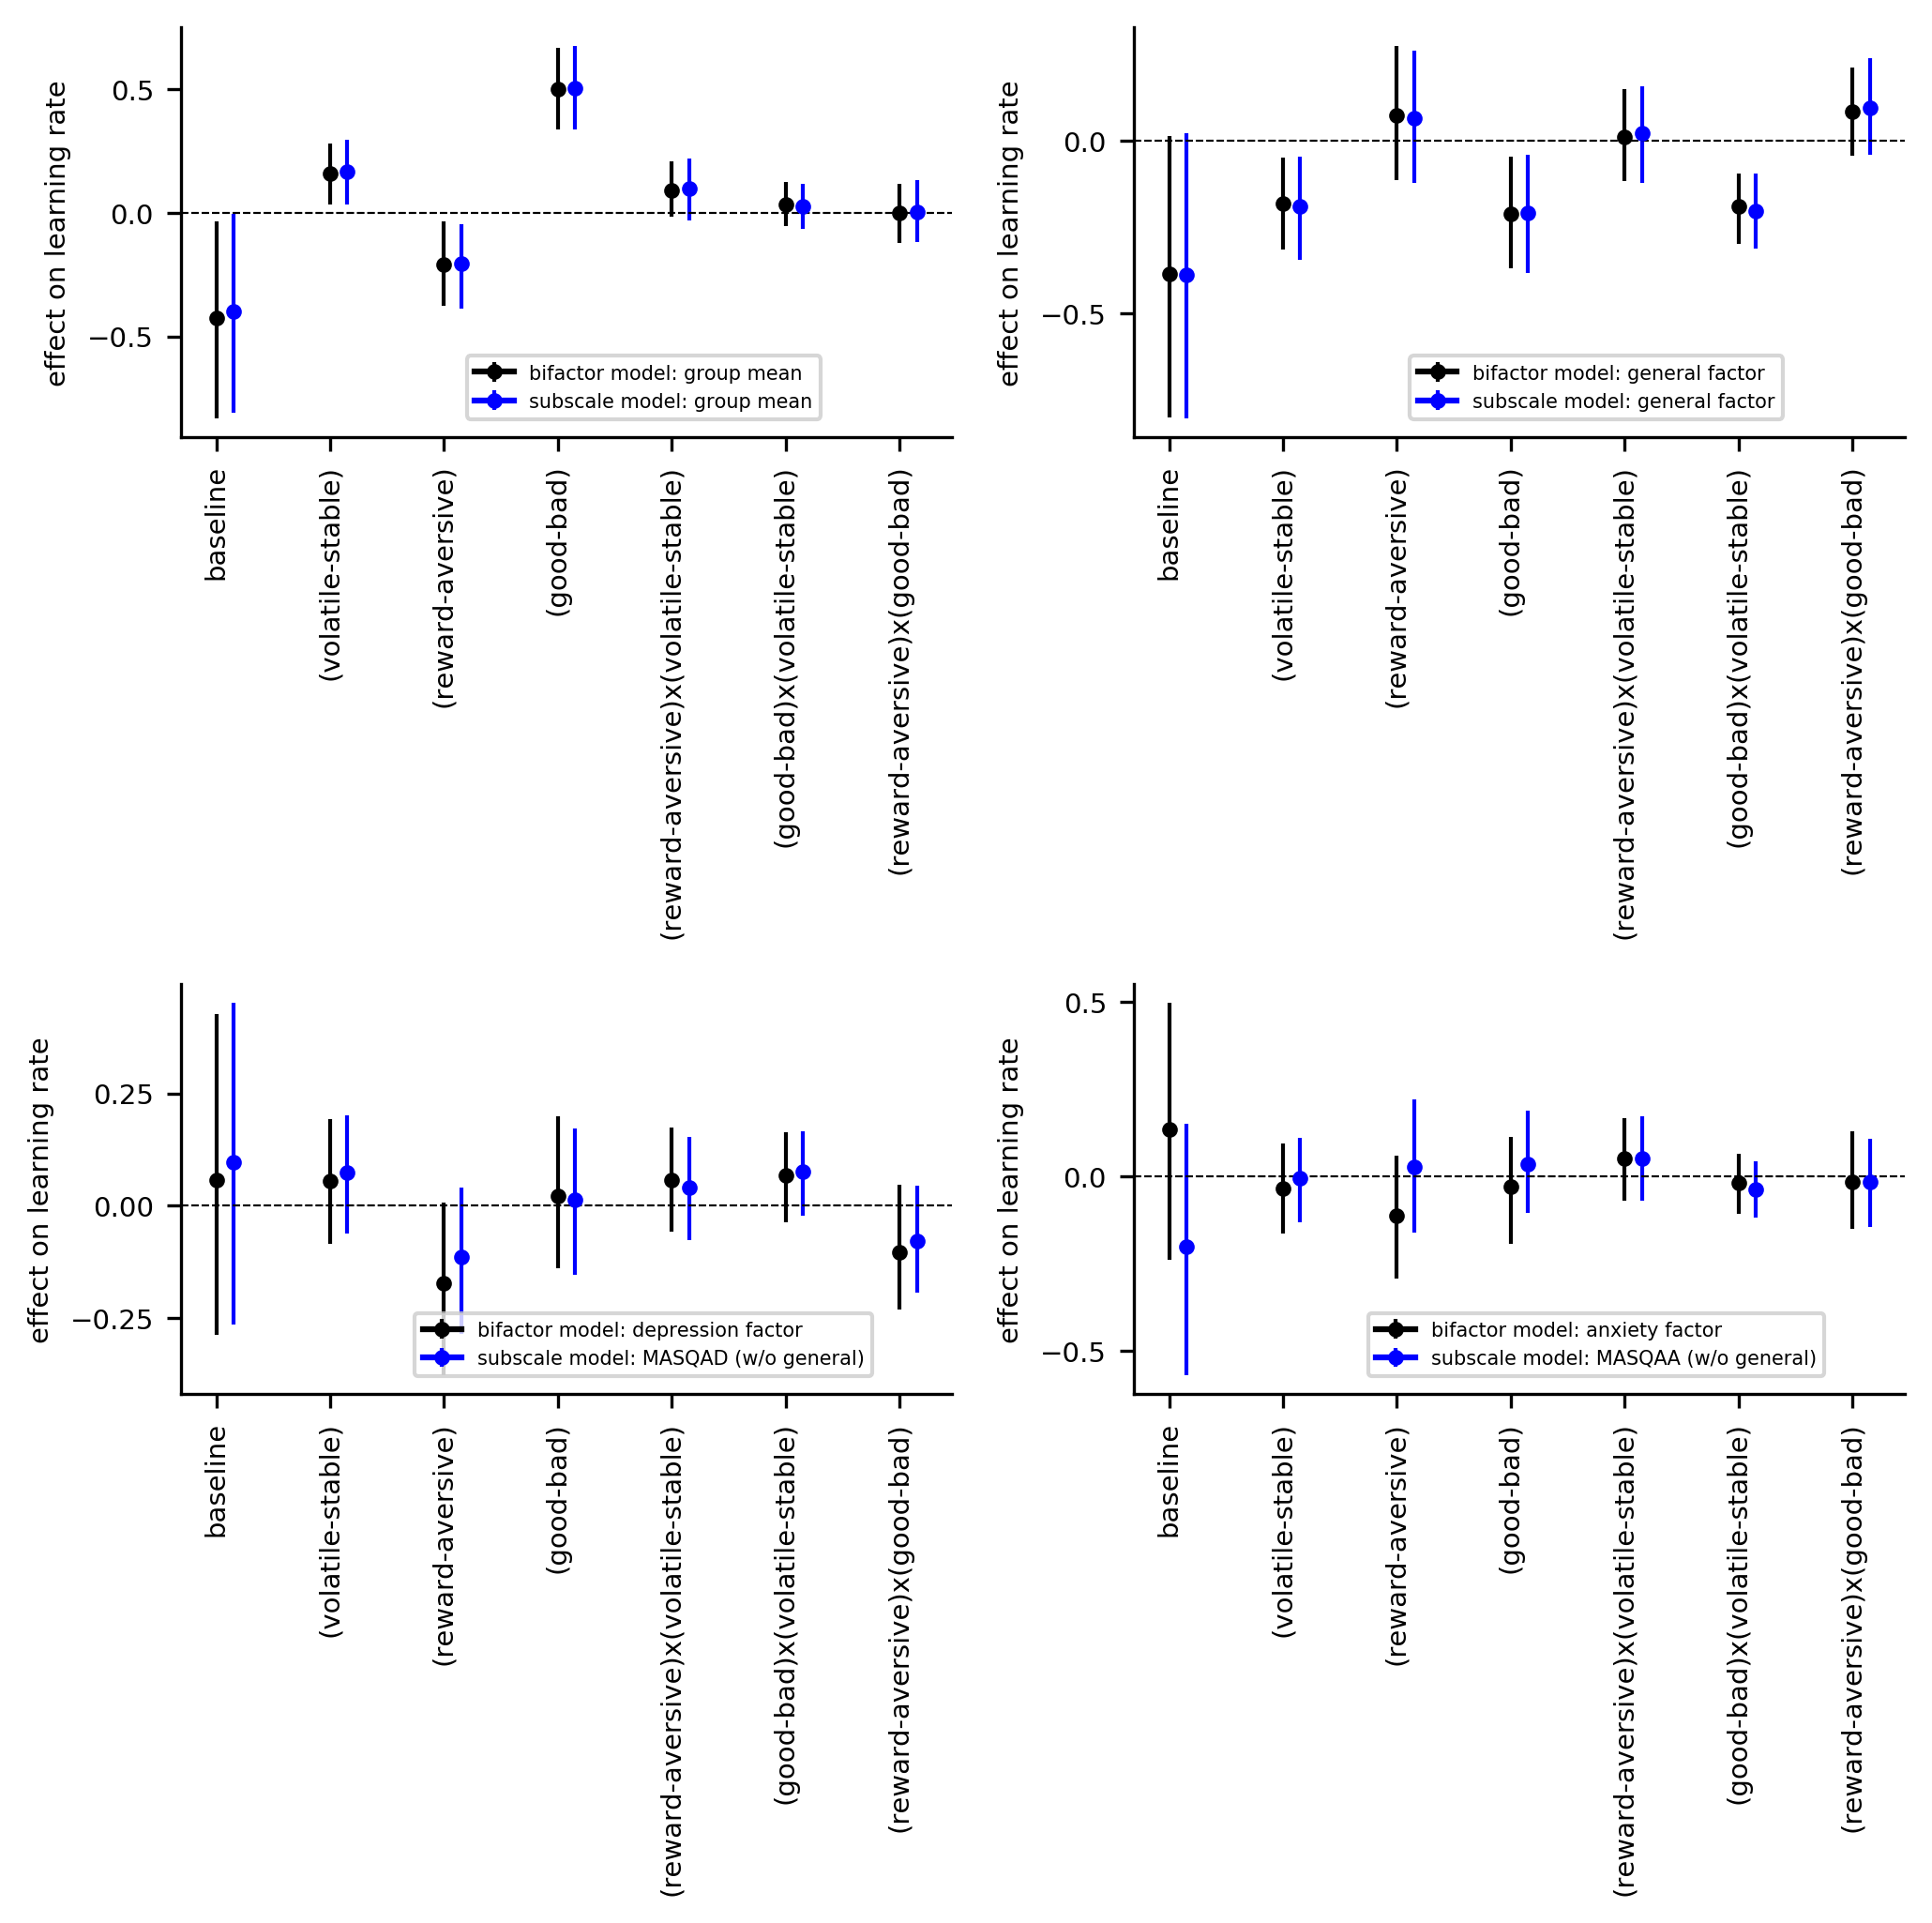

In [265]:

fig,axes  = plt.subplots(2,2,figsize=(7,7),dpi=300)
axes = axes.flatten()

for ax,gparam,gparam_name,gparam_name2 in zip(axes,
                                 ['u','u_PC1','u_PC2','u_PC3'],
                                 ['group mean','general factor','depression factor','anxiety factor'],
                                 ['group mean','general factor','MASQAD (w/o general)','MASQAA (w/o general)']):

    
    plot_param_posterior_errorbars_onesubplot(trace=trace_main, # data
                        params=model_main.params, # model parameter names 
                        gp=gparam, # group parameter 
                        param = 'lr', # readable name 
                        online=False, # different name replacing
                        scale='logit',
                        flipstab=True,
                        mode=False, # use posteriod mode or mean
                        offset=0,
                        ax=ax,# plot characteristics 
                        color='k', 
                        legend=True,
                        title=None,
                        legendlabel='bifactor model: '+gparam_name,
                        ylabel='effect on learning rate',
                        ylabelsize =7,
                        xlabelsize = 7,
                        titlesize = 7,
                        xticklabelsize=7,
                        yticklabelsize=7,
                        legendsize=5,
                        s_bar=3,
                        elinewidth=1,
                        legend_anchor=[0.6,0.02],
                        name_replace=name_replace_nounderscores)
    
    plot_param_posterior_errorbars_onesubplot(trace=trace, # data
                params=model.params, # model parameter names 
                gp=gparam, # group parameter 
                param = 'lr', # readable name 
                online=False, # different name replacing
                scale='logit',
                flipstab=True,
                mode=False, # use posteriod mode or mean
                offset=0.15,
                ax=ax,# plot characteristics 
                color='b', 
                legend=True,
                title=None,
                legendlabel='subscale model: '+gparam_name2,
                ylabel='effect on learning rate',
                ylabelsize =7,
                xlabelsize = 7,
                titlesize = 7,
                xticklabelsize=7,
                yticklabelsize=7,
                legendsize=5,
                s_bar=3,
                elinewidth=1,
                legend_anchor=[0.6,0.02],
                name_replace=name_replace_nounderscores)
    
    
plt.tight_layout()

plt.savefig('../figures/supp_G_ADrG_AArG_3factor_model_learning_rates_group.png',bbox_inches='tight',dpi=500)

## PC1 + MASQADresidPC1 + PSWQresidPC1

In [266]:
# load the model 
model_name = 'model_flex_both_PC1_ADrP_PSWQrP_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_9_23_2000_3all__cdm.pkl'
with open('../fitting_behavioral_model_exp1/model_fits/'+model_name, "rb" ) as buff:
    model_output = pickle.load(buff)
trace=model_output['trace']
ppc=model_output['ppc']
model=model_output['model']

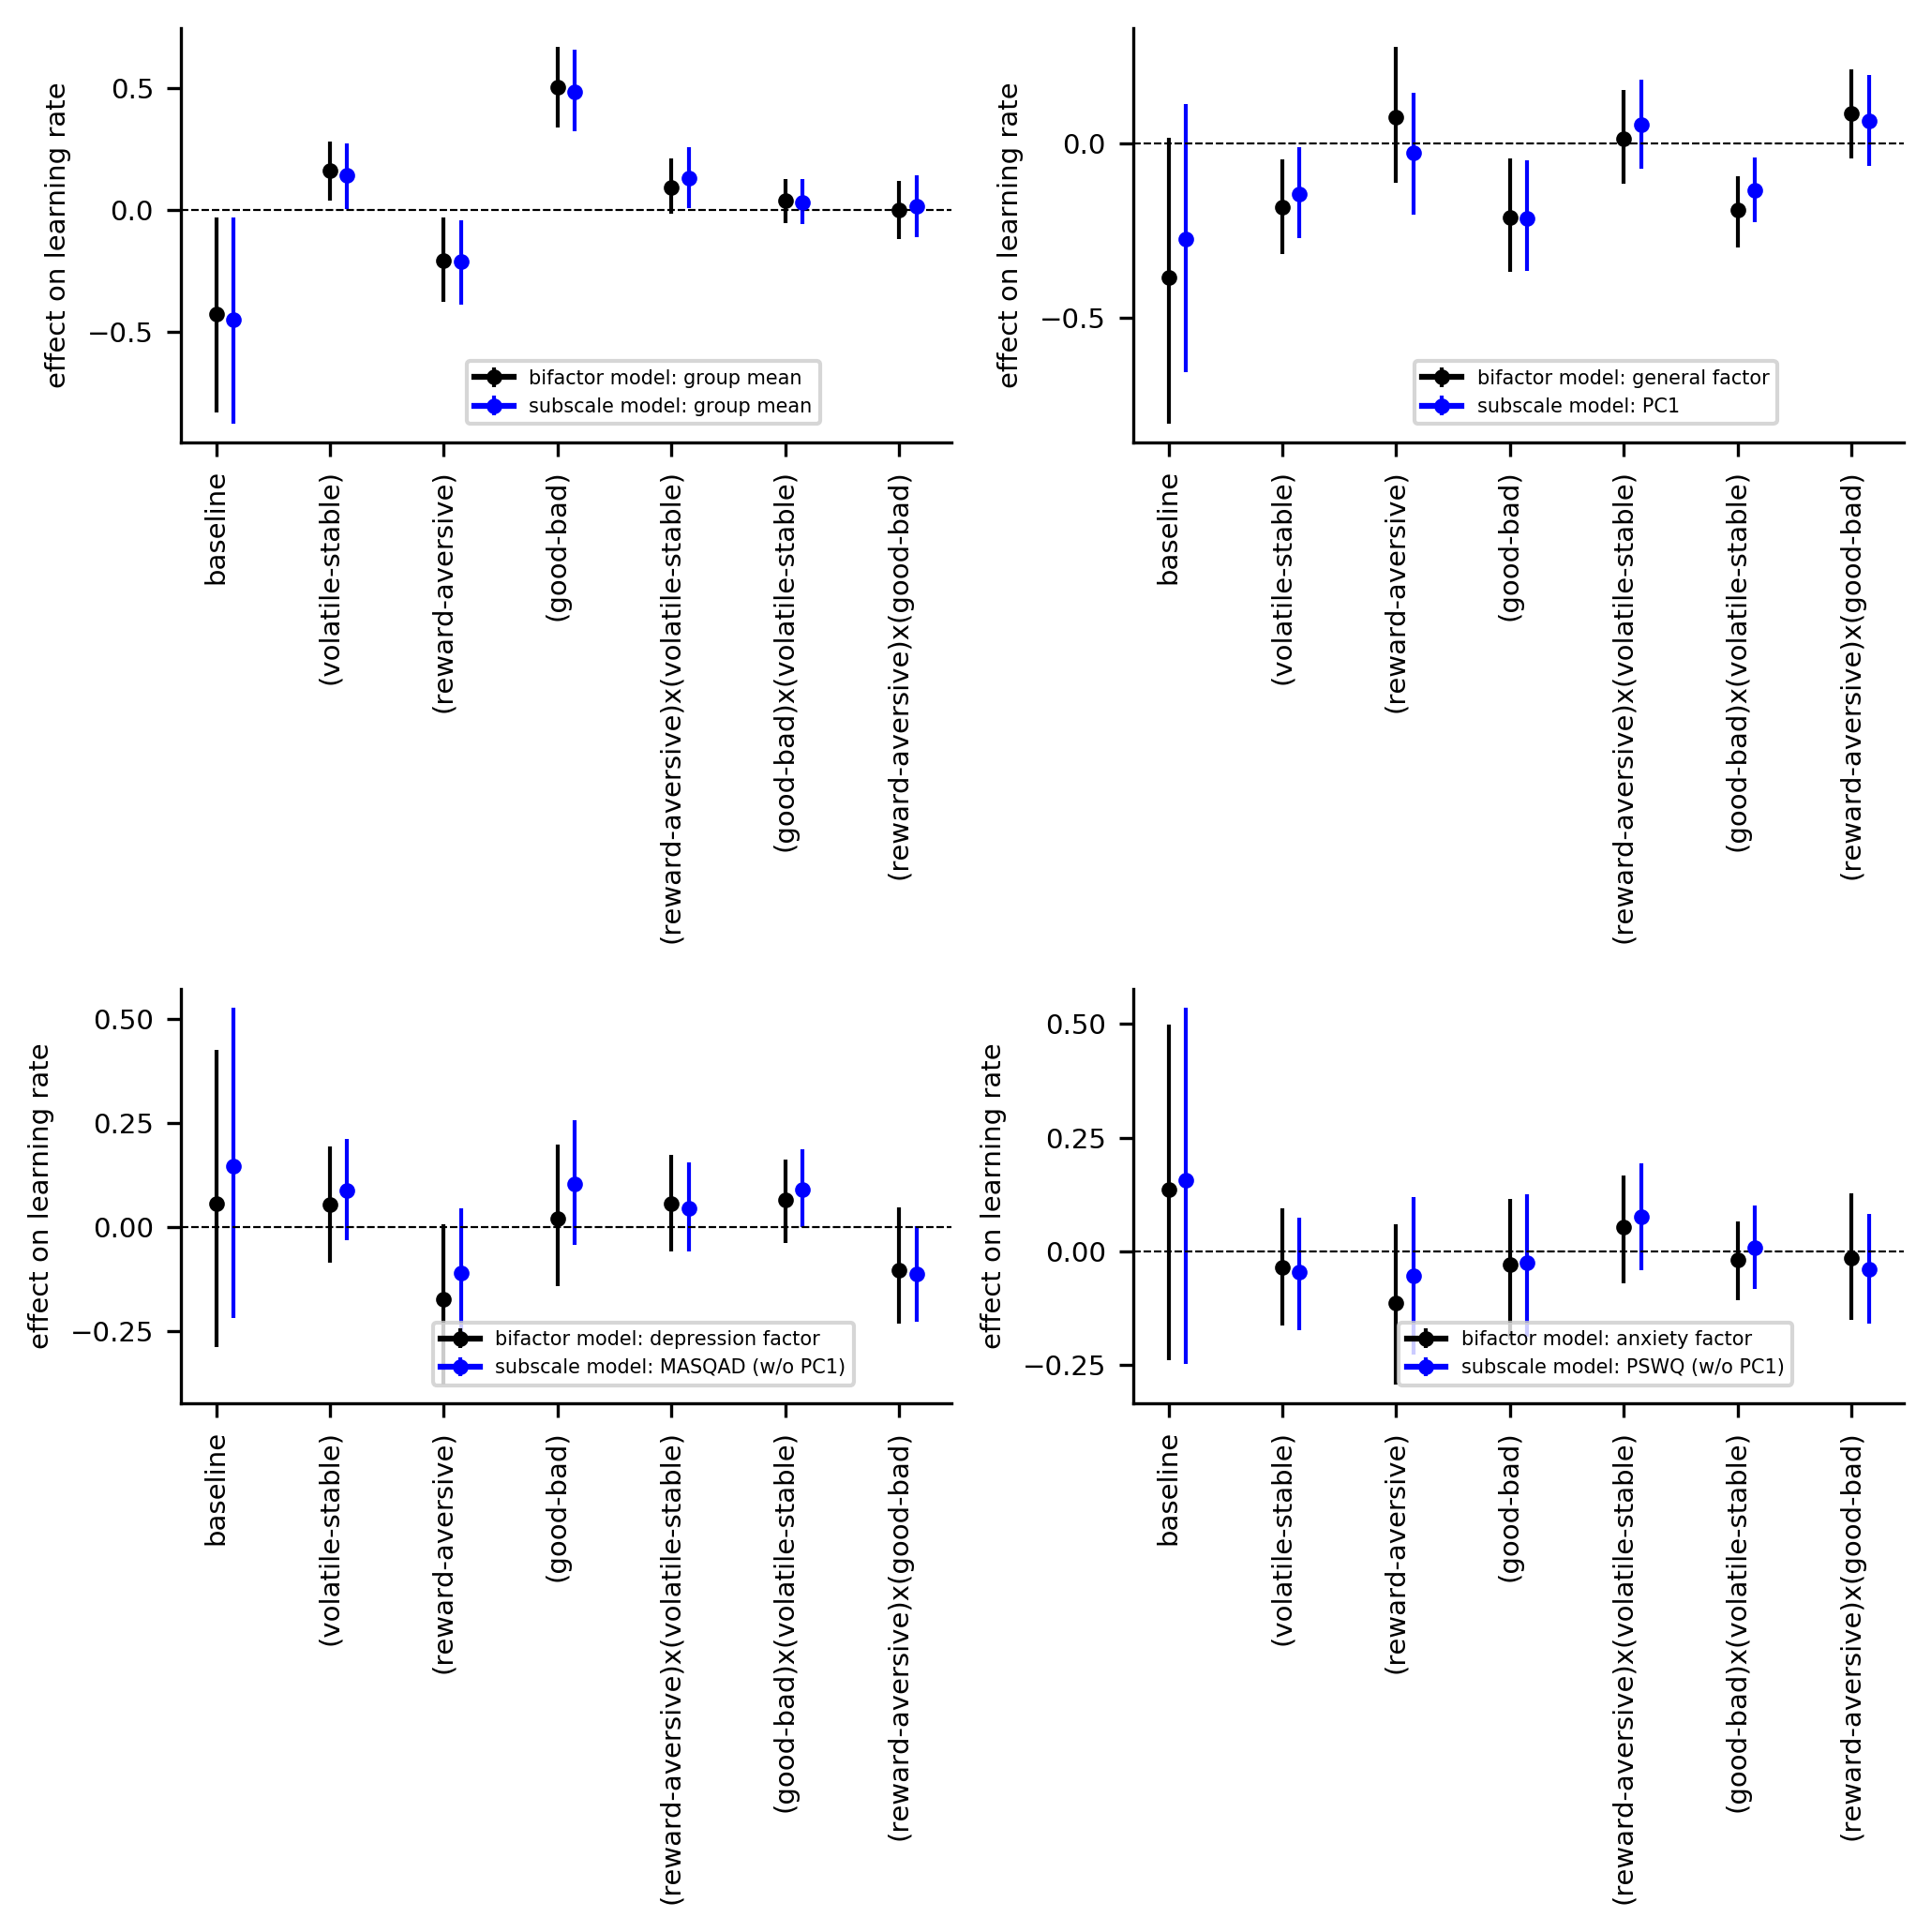

In [267]:

fig,axes  = plt.subplots(2,2,figsize=(7,7),dpi=300)
axes = axes.flatten()


for ax,gparam,gparam_name,gparam_name2 in zip(axes,
                                 ['u','u_PC1','u_PC2','u_PC3'],
                                 ['group mean','general factor','depression factor','anxiety factor'],
                                 ['group mean','PC1','MASQAD (w/o PC1)','PSWQ (w/o PC1)']):

    
    plot_param_posterior_errorbars_onesubplot(trace=trace_main, # data
                        params=model_main.params, # model parameter names 
                        gp=gparam, # group parameter 
                        param = 'lr', # readable name 
                        online=False, # different name replacing
                        scale='logit',
                        flipstab=True,
                        mode=False, # use posteriod mode or mean
                        offset=0,
                        ax=ax,# plot characteristics 
                        color='k', 
                        legend=True,
                        title=None,
                        legendlabel='bifactor model: '+gparam_name,
                        ylabel='effect on learning rate',
                        ylabelsize =7,
                        xlabelsize = 7,
                        titlesize = 7,
                        xticklabelsize=7,
                        yticklabelsize=7,
                        legendsize=5,
                        s_bar=3,
                        elinewidth=1,
                        legend_anchor=[0.6,0.02],
                        name_replace=name_replace_nounderscores)
    
    plot_param_posterior_errorbars_onesubplot(trace=trace, # data
                params=model.params, # model parameter names 
                gp=gparam, # group parameter 
                param = 'lr', # readable name 
                online=False, # different name replacing
                scale='logit',
                flipstab=True,
                mode=False, # use posteriod mode or mean
                offset=0.15,
                ax=ax,# plot characteristics 
                color='b', 
                legend=True,
                title=None,
                legendlabel='subscale model: '+gparam_name2,
                ylabel='effect on learning rate',
                ylabelsize =7,
                xlabelsize = 7,
                titlesize = 7,
                xticklabelsize=7,
                yticklabelsize=7,
                legendsize=5,
                s_bar=3,
                elinewidth=1,
                legend_anchor=[0.6,0.02],
                name_replace=name_replace_nounderscores)
    
plt.tight_layout()

    

#plt.savefig('../figures/supp_G_ADrG_AArG_3factor_model_learning_rates_group.png',bbox_inches='tight',dpi=500)

## 3

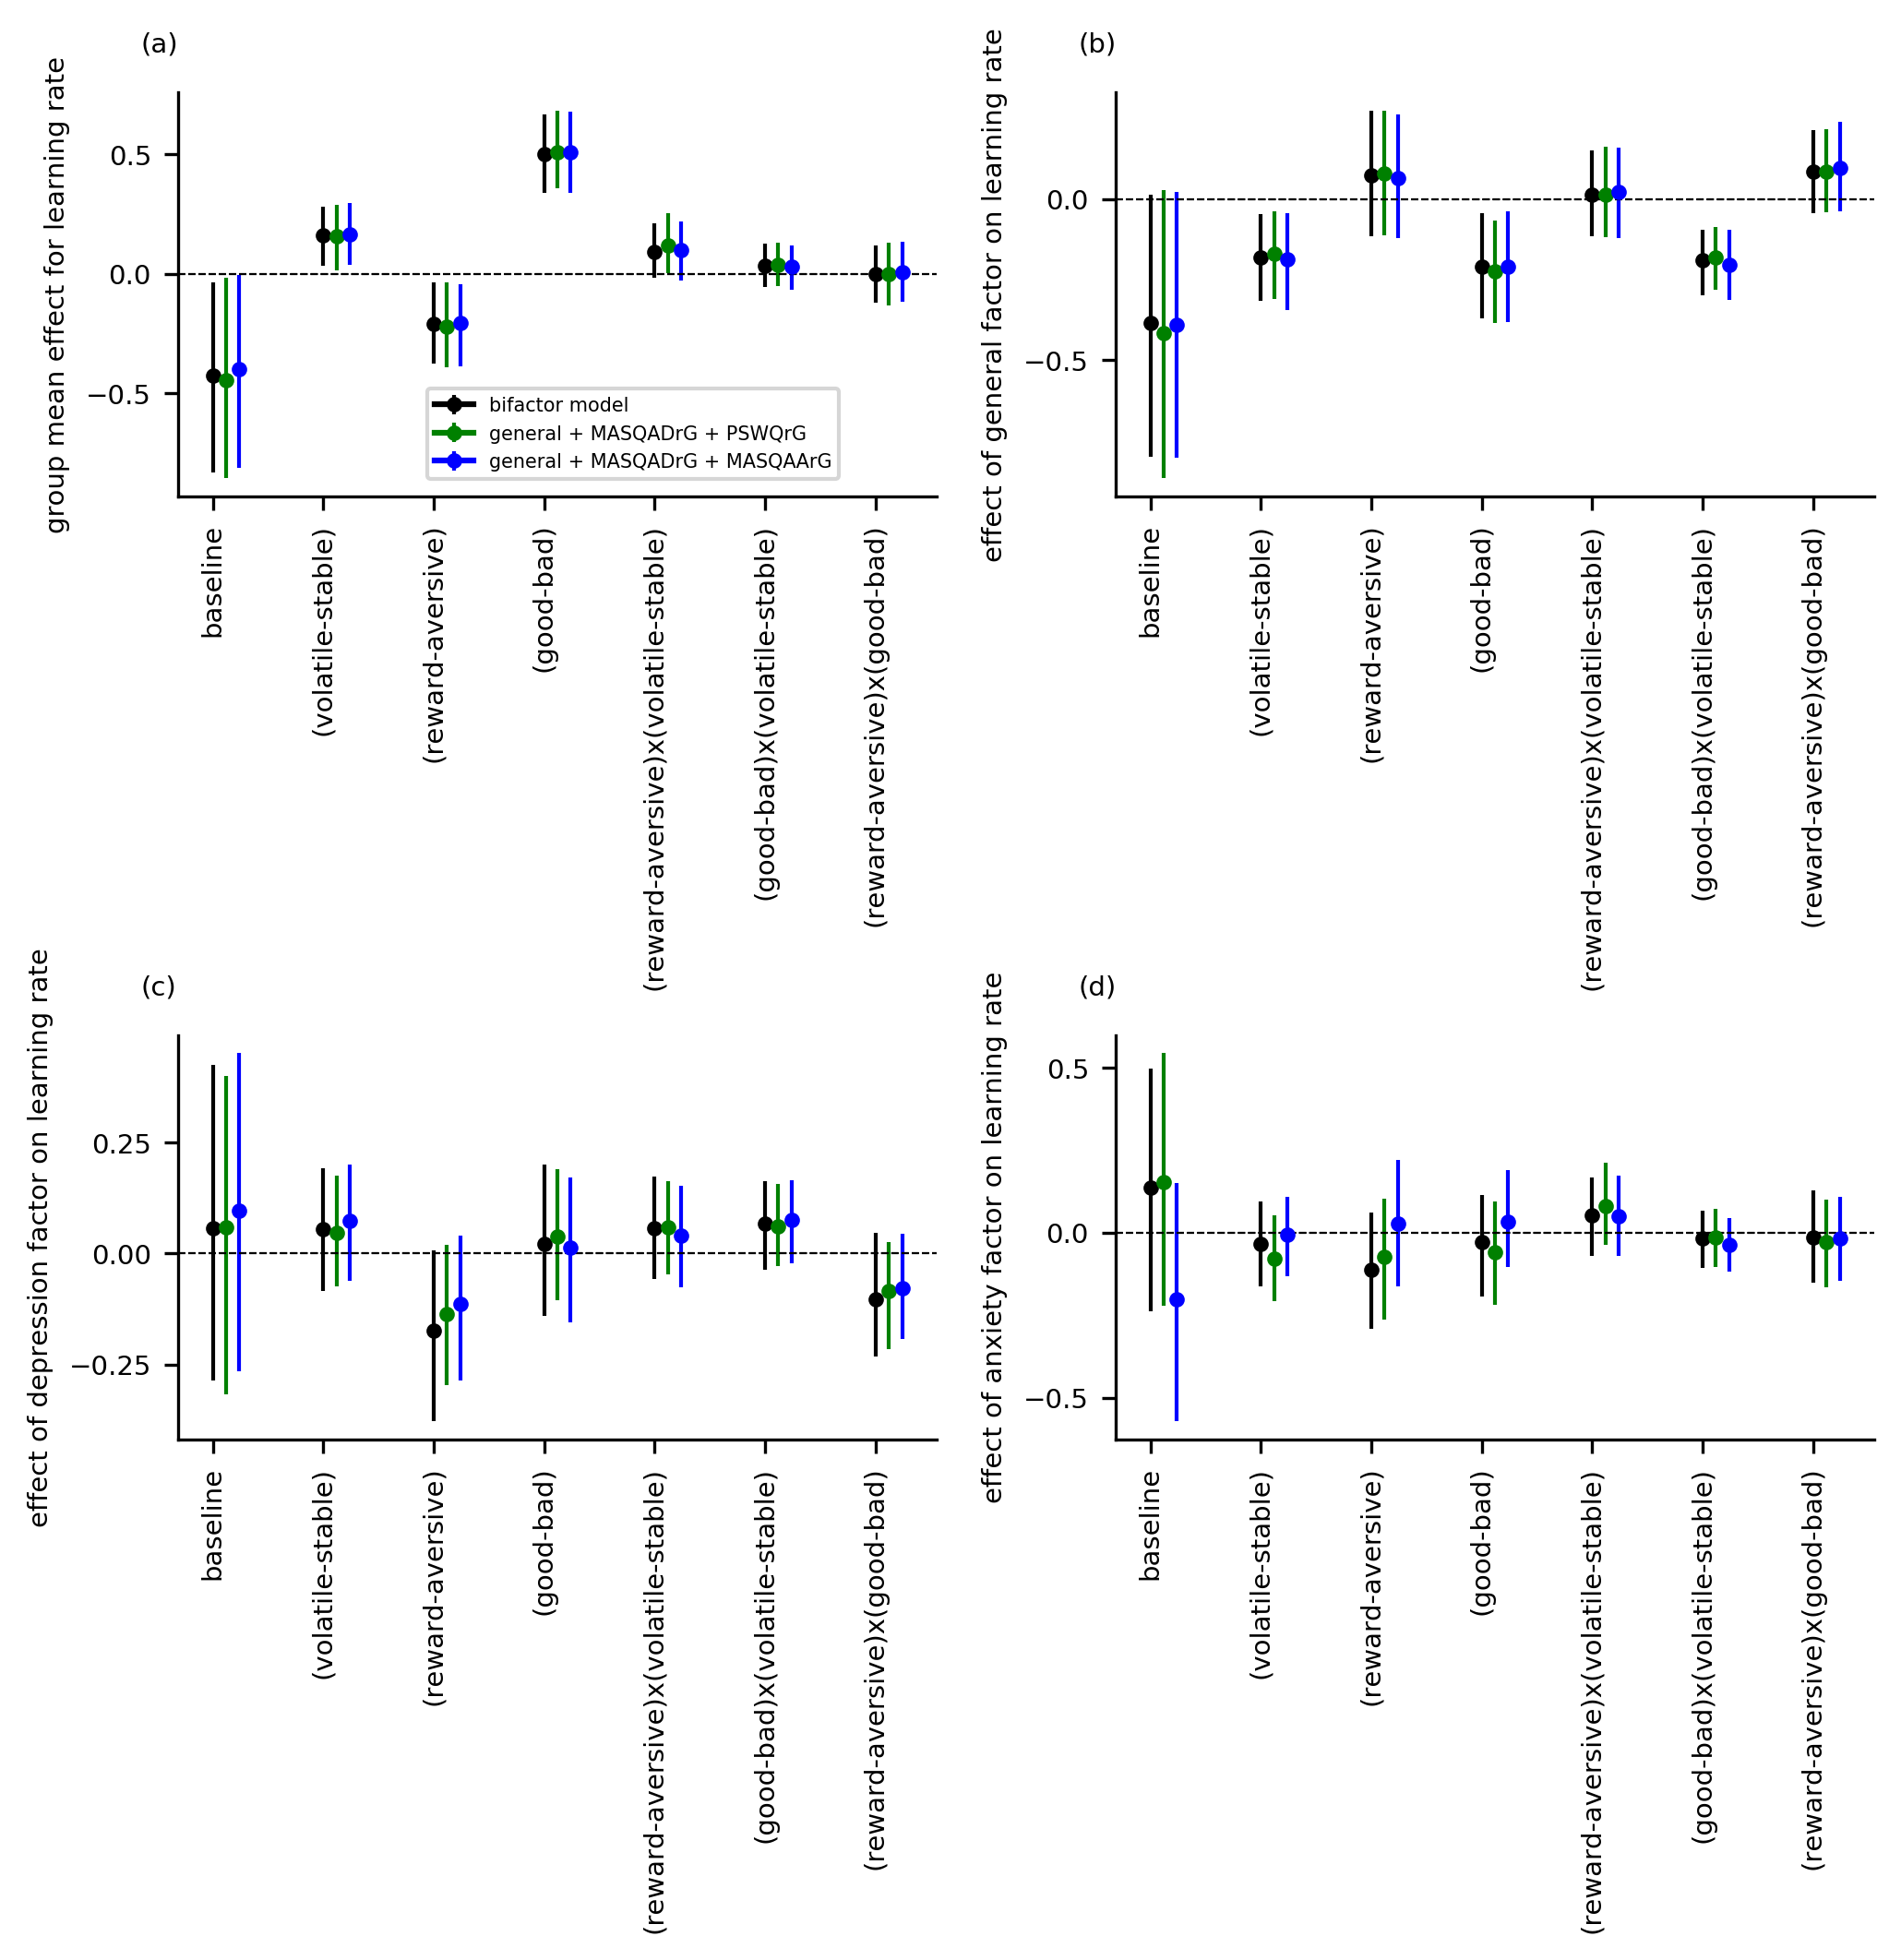

In [147]:

fig,axes  = plt.subplots(2,2,figsize=(7,7),dpi=300)
axes = axes.flatten()

gi = 0
for model_name_short, model_name,gnames,color in zip(
    ['bifactor model','general + MASQADrG + PSWQrG','general + MASQADrG + MASQAArG'],
    ['model_flex_both_Bi3itemCDM_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_4_27_2000_3all__cdm.pkl',
    'model_flex_both_G_ADrG_PSWQrG_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_10_2_2000_3all__cdm.pkl',
     'model_flex_both_G_ADrG_AArG_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_10_2_2000_3all__cdm.pkl'],
                             [['group mean','general factor','depression factor','anxiety factor'],
                              ['group mean','general factor','depression factor','anxiety factor'],
                              ['group mean','general factor','depression factor','anxiety factor'],
                              ],['k','g','b','r']):
                              
    
    with open('../fitting_behavioral_model_exp1/model_fits/'+model_name, "rb" ) as buff:
        model_output = pickle.load(buff)
    trace=model_output['trace']
    ppc=model_output['ppc']
    model=model_output['model']
    
    
    
    for ax,gparam,gparam_name in zip(axes,
                                     ['u','u_PC1','u_PC2','u_PC3'],
                                     gnames):

        if gparam=='u':
            legendBOOL=True
        else:
            legendBOOL=False
            
        if gparam=='u':
            ylabel=gparam_name+' effect for learning rate'
        else:
            ylabel='effect of '+gparam_name+' on learning rate'
            
        plot_param_posterior_errorbars_onesubplot(trace=trace, # data
                            params=model.params, # model parameter names 
                            gp=gparam, # group parameter 
                            param = 'lr', # readable name 
                            online=False, # different name replacing
                            scale='logit',
                            flipstab=True,
                            mode=False, # use posteriod mode or mean
                            offset=0+gi*0.12,
                            ax=ax,# plot characteristics 
                            color=color, 
                            legend=legendBOOL,
                            title=None,
                            legendlabel=model_name_short,
                            ylabel=ylabel,
                            ylabelsize =7,
                            xlabelsize = 7,
                            titlesize = 7,
                            xticklabelsize=7,
                            yticklabelsize=7,
                            legendsize=5,
                            s_bar=3,
                            elinewidth=1,
                            legend_anchor=[0.6,0.02],
                            name_replace=name_replace_nounderscores)


    gi+=1
    
plt.tight_layout()
plt.text(-0.05,1.1,'(a)',fontsize=7,transform=axes[0].transAxes)
plt.text(-0.05,1.1,'(b)',fontsize=7,transform=axes[1].transAxes)
plt.text(-0.05,1.1,'(c)',fontsize=7,transform=axes[2].transAxes)
plt.text(-0.05,1.1,'(d)',fontsize=7,transform=axes[3].transAxes)

    
plt.savefig('../figures/supp_all3_model_learning_rates_group.png',bbox_inches='tight',dpi=500)

# Supplemental Figures with Alternative Models (Exp 2)

## Main Model

In [124]:
# load the model 
model_name='model_flex_both_Bi3itemCDM_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_4_27_2000_3all.pkl'
with open('../fitting_behavioral_model_exp2/model_fits/'+model_name, "rb" ) as buff:
    model_output = pickle.load(buff)
trace_main=model_output['trace']
ppc_main=model_output['ppc']
model_main=model_output['model']

## G + MASQADresidG + MASQAAresidG

In [125]:
# load the model 
model_name = 'model_flex_both_G_ADrG_AArG_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_10_2_2000_3all.pkl'
with open('../fitting_behavioral_model_exp2/model_fits/'+model_name, "rb" ) as buff:
    model_output = pickle.load(buff)
trace=model_output['trace']
ppc=model_output['ppc']
model=model_output['model']

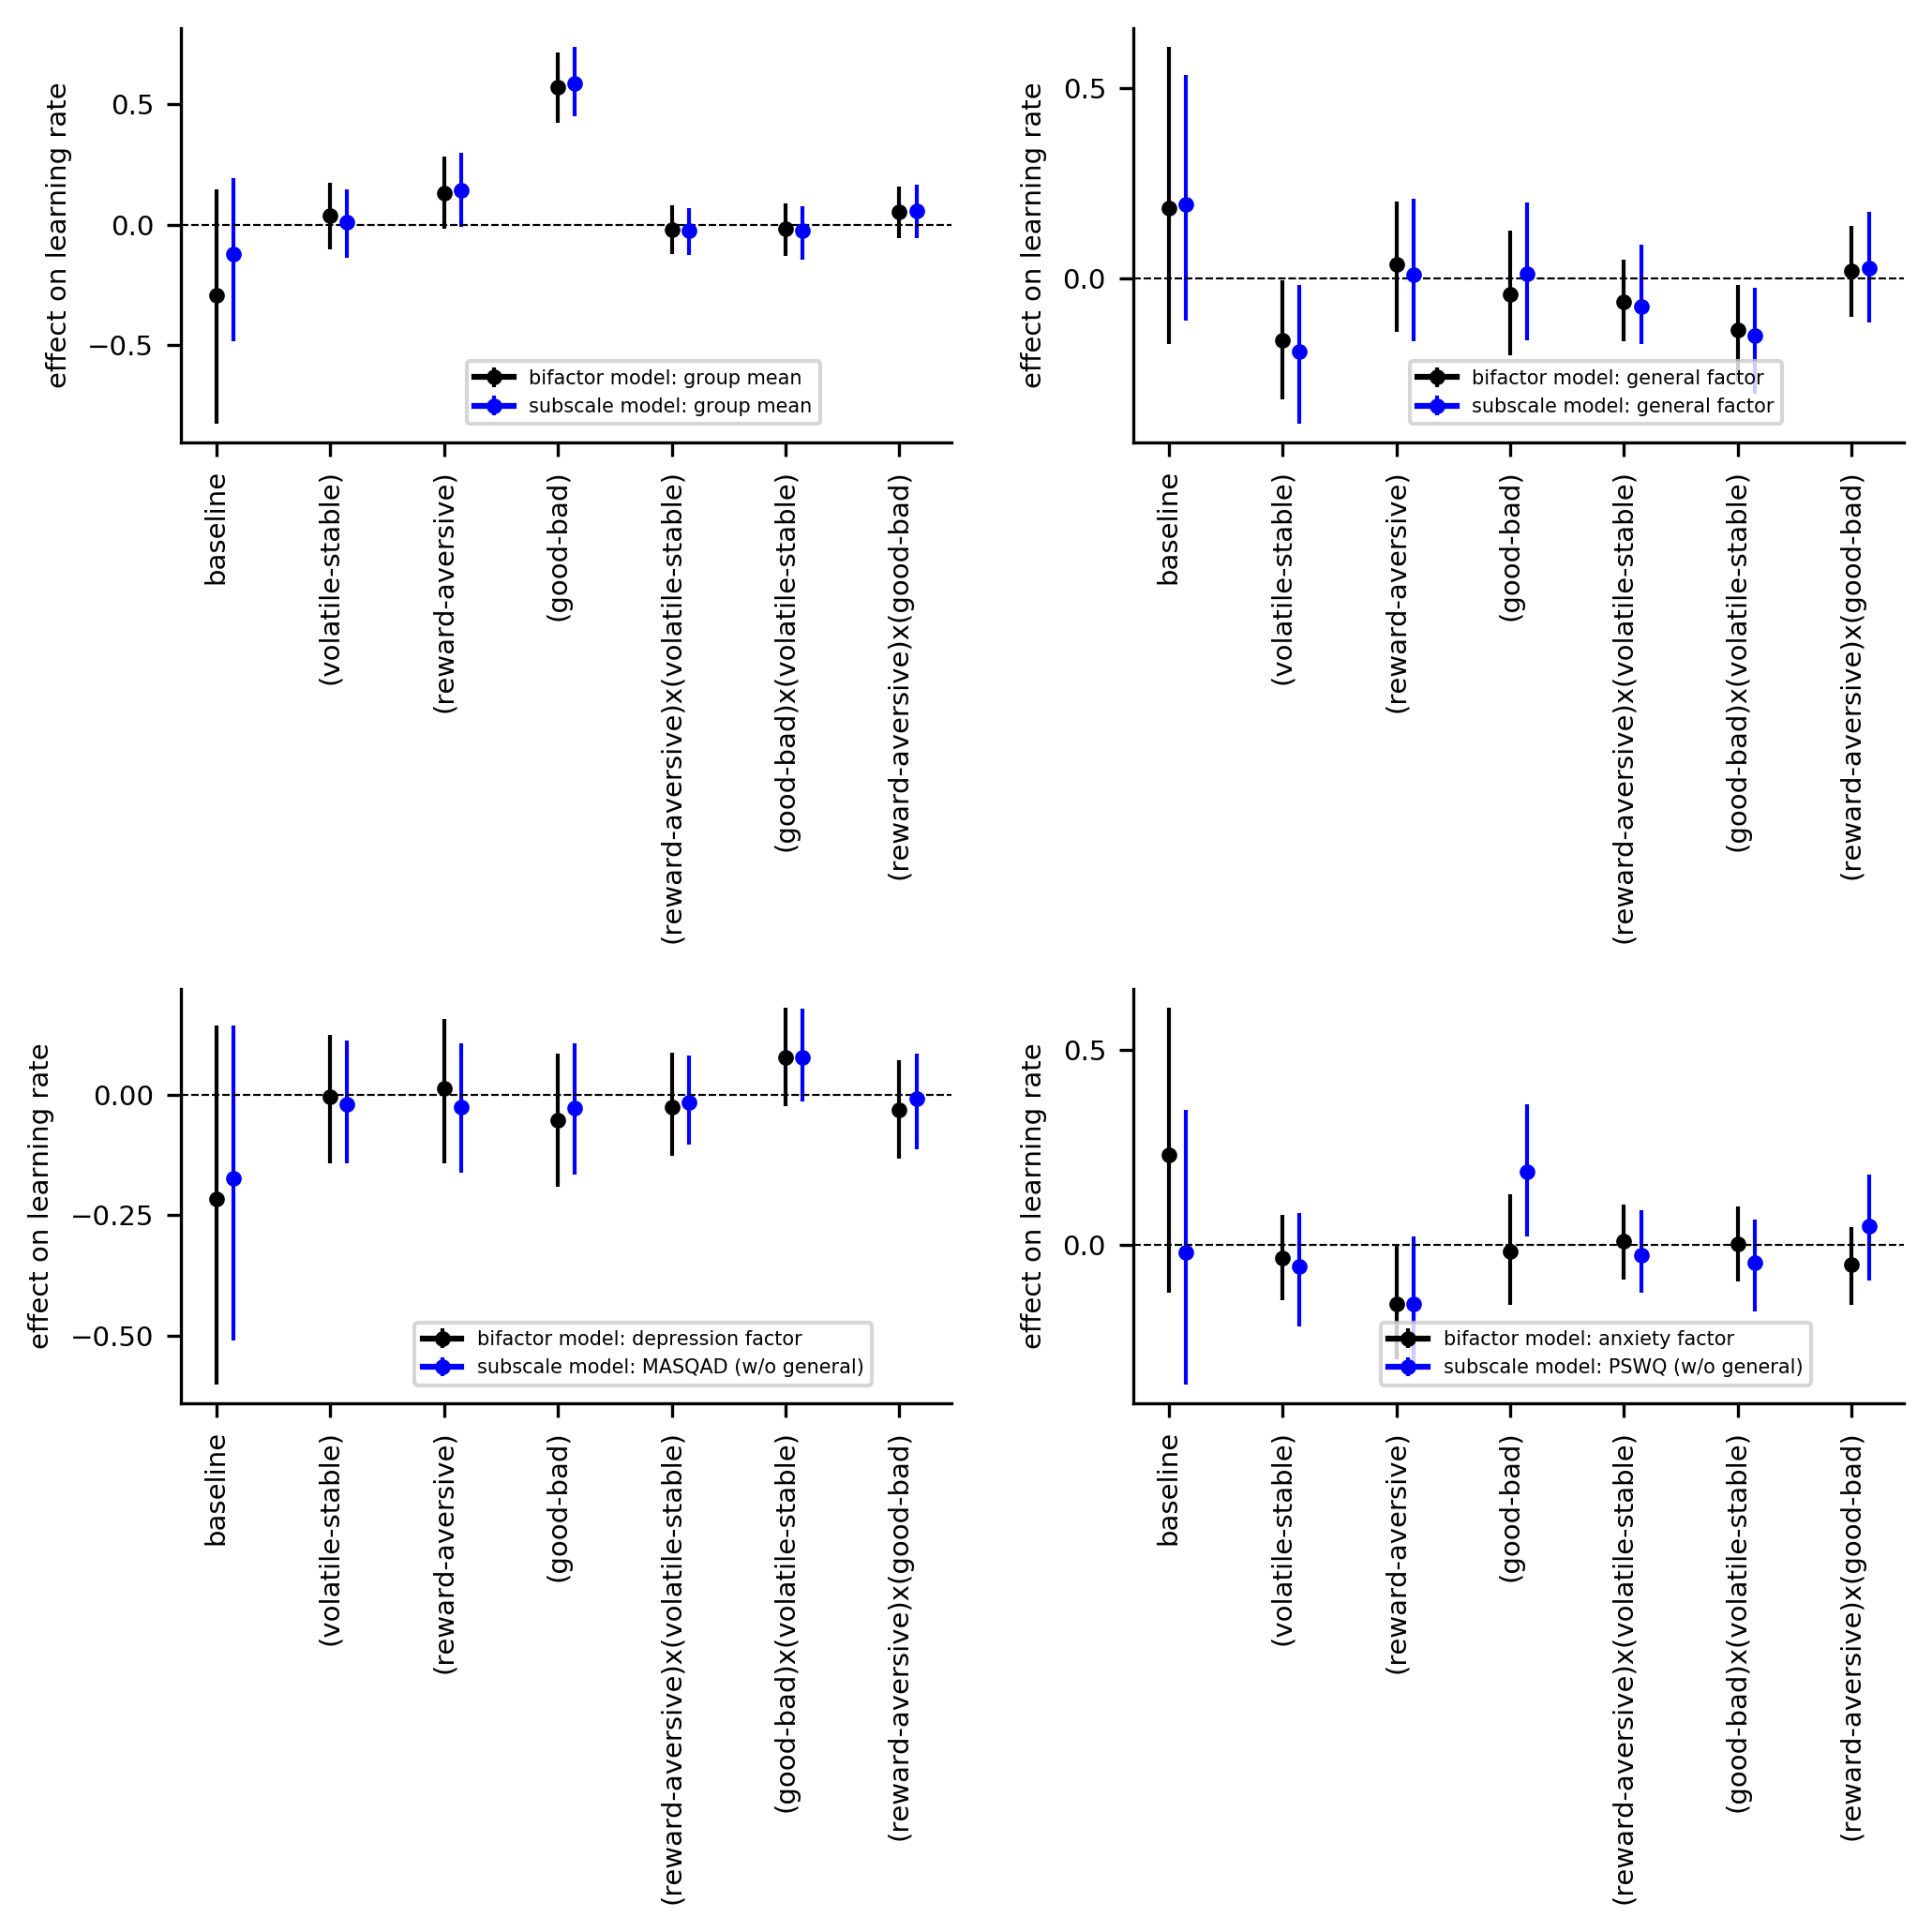

In [270]:

fig,axes  = plt.subplots(2,2,figsize=(7,7),dpi=300)
axes = axes.flatten()

for ax,gparam,gparam_name,gparam_name2 in zip(axes,
                                 ['u','u_PC1','u_PC2','u_PC3'],
                                 ['group mean','general factor','depression factor','anxiety factor'],
                                 ['group mean','general factor','MASQAD (w/o general)','PSWQ (w/o general)']):

    
    plot_param_posterior_errorbars_onesubplot(trace=trace_main, # data
                        params=model_main.params, # model parameter names 
                        gp=gparam, # group parameter 
                        param = 'lr', # readable name 
                        online=False, # different name replacing
                        scale='logit',
                        flipstab=True,
                        mode=False, # use posteriod mode or mean
                        offset=0,
                        ax=ax,# plot characteristics 
                        color='k', 
                        legend=True,
                        title=None,
                        legendlabel='bifactor model: '+gparam_name,
                        ylabel='effect on learning rate',
                        ylabelsize =7,
                        xlabelsize = 7,
                        titlesize = 7,
                        xticklabelsize=7,
                        yticklabelsize=7,
                        legendsize=5,
                        s_bar=3,
                        elinewidth=1,
                        legend_anchor=[0.6,0.02],
                        name_replace=name_replace_nounderscores)
    
    plot_param_posterior_errorbars_onesubplot(trace=trace, # data
                params=model.params, # model parameter names 
                gp=gparam, # group parameter 
                param = 'lr', # readable name 
                online=False, # different name replacing
                scale='logit',
                flipstab=True,
                mode=False, # use posteriod mode or mean
                offset=0.15,
                ax=ax,# plot characteristics 
                color='b', 
                legend=True,
                title=None,
                legendlabel='subscale model: '+gparam_name2,
                ylabel='effect on learning rate',
                ylabelsize =7,
                xlabelsize = 7,
                titlesize = 7,
                xticklabelsize=7,
                yticklabelsize=7,
                legendsize=5,
                s_bar=3,
                elinewidth=1,
                legend_anchor=[0.6,0.02],
                name_replace=name_replace_nounderscores)
    
plt.tight_layout()

#plt.savefig('../figures/supp_G_ADrG_PSWQrG_3factor_model_learning_rates_group.png',bbox_inches='tight',dpi=500)

## PC1 + MASQADresidPC1 + MASQAAresidPC1

In [258]:
# load the model 
model_name = 'model_flex_both_PC1_ADrP_AArP_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_9_23_2000_3all.pkl'
with open('../fitting_behavioral_model_exp2/model_fits/'+model_name, "rb" ) as buff:
    model_output = pickle.load(buff)
trace=model_output['trace']
ppc=model_output['ppc']
model=model_output['model']

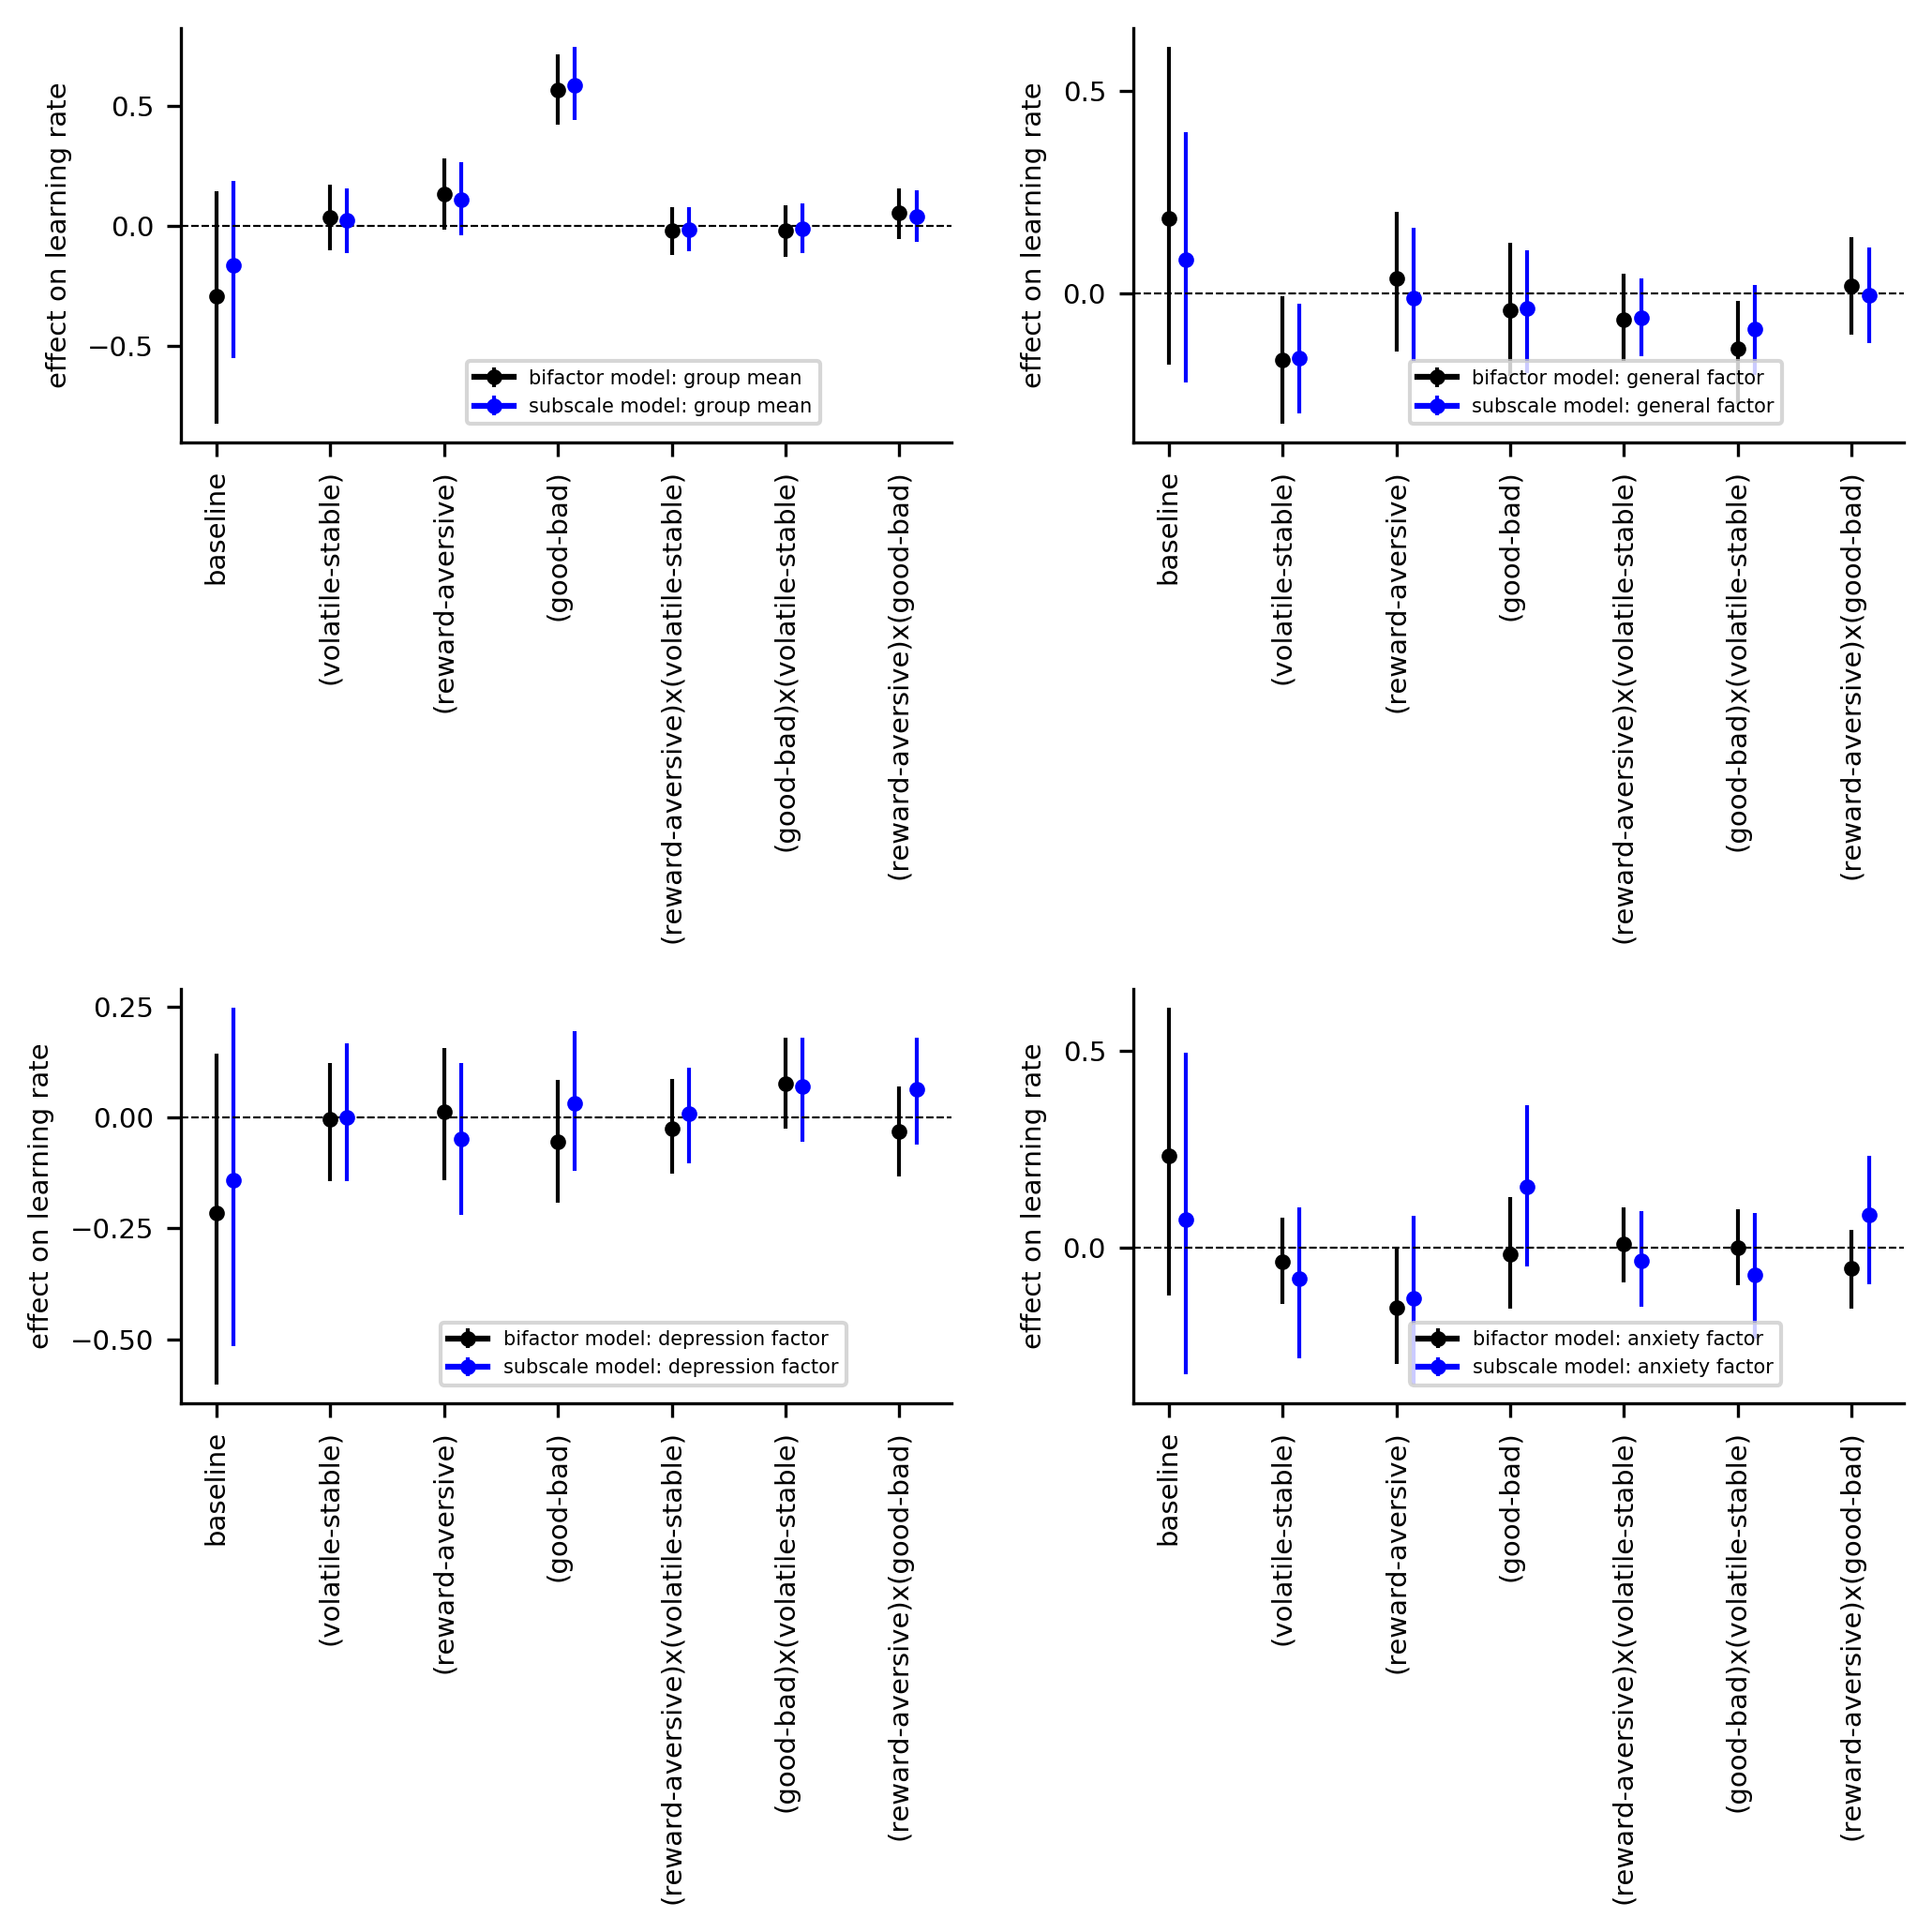

In [259]:

fig,axes  = plt.subplots(2,2,figsize=(7,7),dpi=300)
axes = axes.flatten()

for ax,gparam,gparam_name,gparam_name2 in zip(axes,
                                 ['u','u_PC1','u_PC2','u_PC3'],
                                 ['group mean','general factor','depression factor','anxiety factor'],
                                 ['group mean','general factor','MASQAD (w/o general)','PSWQ (w/o general)']):

    
    plot_param_posterior_errorbars_onesubplot(trace=trace_main, # data
                        params=model_main.params, # model parameter names 
                        gp=gparam, # group parameter 
                        param = 'lr', # readable name 
                        online=False, # different name replacing
                        scale='logit',
                        flipstab=True,
                        mode=False, # use posteriod mode or mean
                        offset=0,
                        ax=ax,# plot characteristics 
                        color='k', 
                        legend=True,
                        title=None,
                        legendlabel='bifactor model: '+gparam_name,
                        ylabel='effect on learning rate',
                        ylabelsize =7,
                        xlabelsize = 7,
                        titlesize = 7,
                        xticklabelsize=7,
                        yticklabelsize=7,
                        legendsize=5,
                        s_bar=3,
                        elinewidth=1,
                        legend_anchor=[0.6,0.02],
                        name_replace=name_replace_nounderscores)
    
    plot_param_posterior_errorbars_onesubplot(trace=trace, # data
                params=model.params, # model parameter names 
                gp=gparam, # group parameter 
                param = 'lr', # readable name 
                online=False, # different name replacing
                scale='logit',
                flipstab=True,
                mode=False, # use posteriod mode or mean
                offset=0.15,
                ax=ax,# plot characteristics 
                color='b', 
                legend=True,
                title=None,
                legendlabel='subscale model: '+gparam_name,
                ylabel='effect on learning rate',
                ylabelsize =7,
                xlabelsize = 7,
                titlesize = 7,
                xticklabelsize=7,
                yticklabelsize=7,
                legendsize=5,
                s_bar=3,
                elinewidth=1,
                legend_anchor=[0.6,0.02],
                name_replace=name_replace_nounderscores)
    
plt.tight_layout()

#plt.savefig('../figures/supp_G_ADrG_PSWQrG_3factor_model_learning_rates_group.png',bbox_inches='tight',dpi=500)

## 2

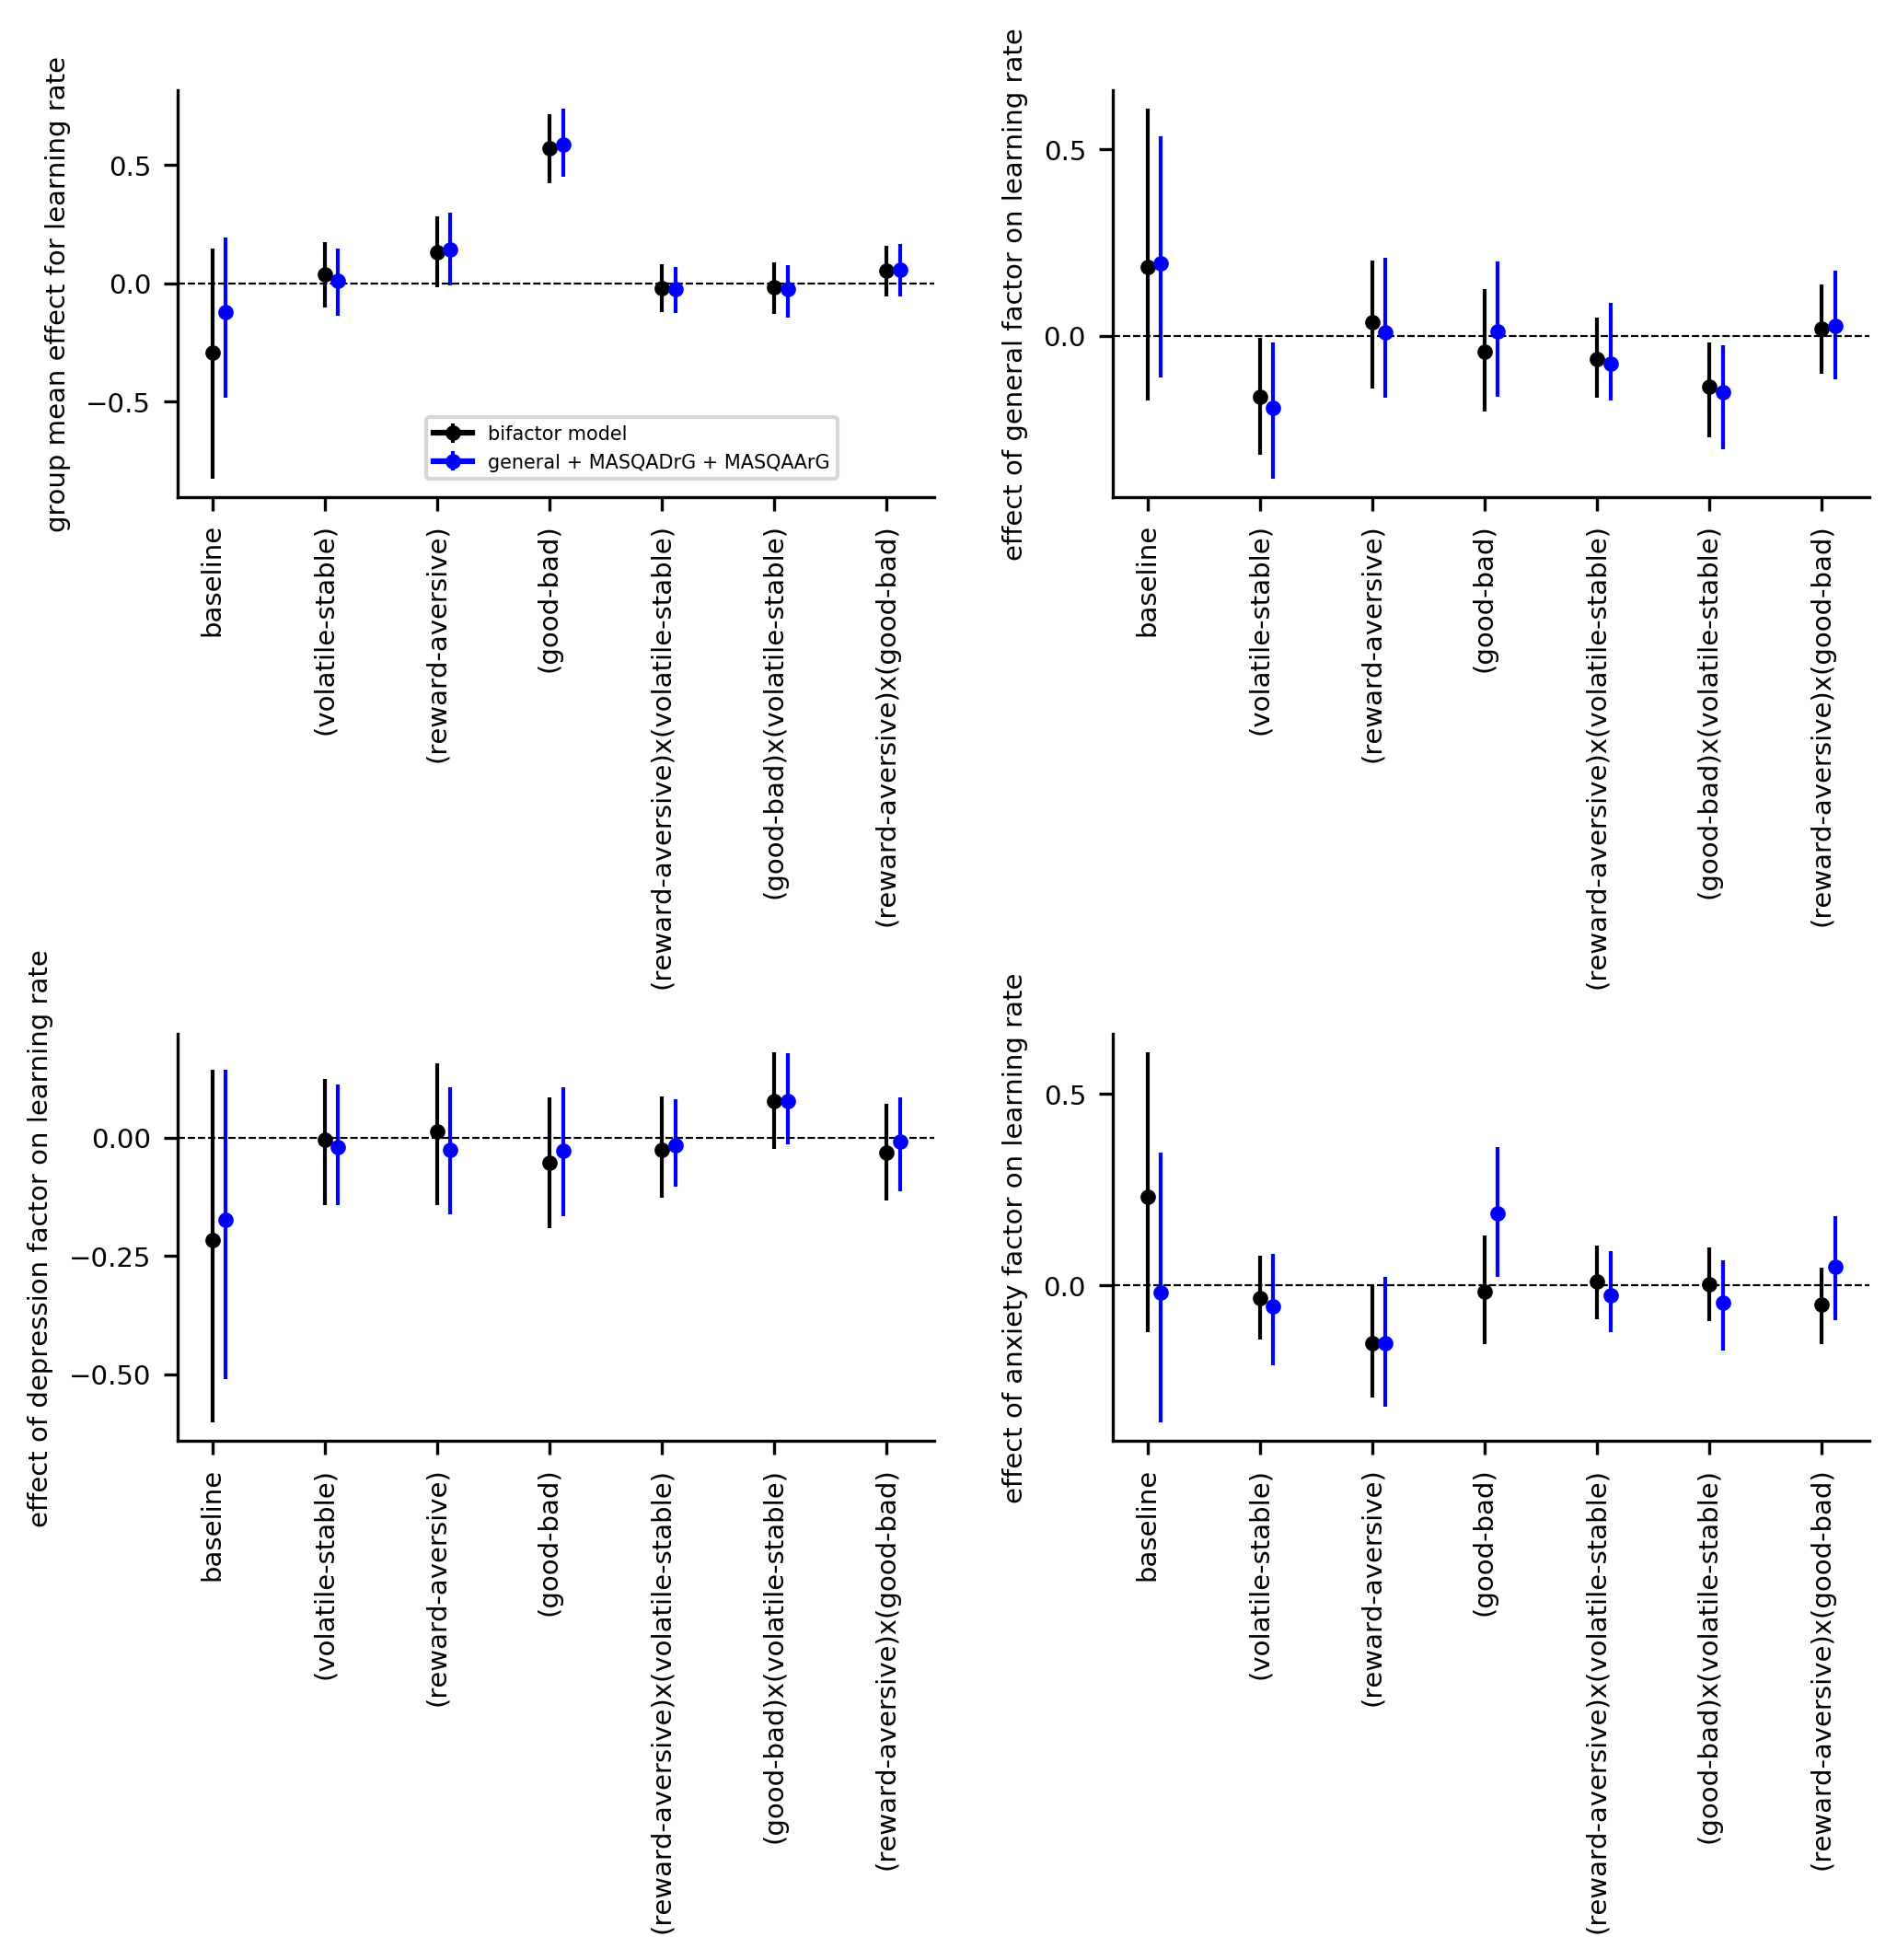

In [126]:

fig,axes  = plt.subplots(2,2,figsize=(7,7),dpi=300)
axes = axes.flatten()

gi = 0
for model_name_short, model_name,gnames,color in zip(
    ['bifactor model','general + MASQADrG + MASQAArG',],
    ['model_flex_both_Bi3itemCDM_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_4_27_2000_3all.pkl',
    'model_flex_both_G_ADrG_AArG_single+goodbad(all)+smag+ckernel(rewpain)_hier_2020_10_2_2000_3all.pkl'],
                             [['group mean','general factor','depression factor','anxiety factor'],
                              ['group mean','general factor','depression factor','anxiety factor']],['k','b','r']):
                              
    
    with open('../fitting_behavioral_model_exp2/model_fits/'+model_name, "rb" ) as buff:
        model_output = pickle.load(buff)
    trace=model_output['trace']
    ppc=model_output['ppc']
    model=model_output['model']
    
    
    
    for ax,gparam,gparam_name in zip(axes,
                                     ['u','u_PC1','u_PC2','u_PC3'],
                                     gnames):

        if gparam=='u':
            legendBOOL=True
        else:
            legendBOOL=False
            
        if gparam=='u':
            ylabel=gparam_name+' effect for learning rate'
        else:
            ylabel='effect of '+gparam_name+' on learning rate'
            
        plot_param_posterior_errorbars_onesubplot(trace=trace, # data
                            params=model.params, # model parameter names 
                            gp=gparam, # group parameter 
                            param = 'lr', # readable name 
                            online=False, # different name replacing
                            scale='logit',
                            flipstab=True,
                            mode=False, # use posteriod mode or mean
                            offset=0+gi*0.12,
                            ax=ax,# plot characteristics 
                            color=color, 
                            legend=legendBOOL,
                            title=None,
                            legendlabel=model_name_short,
                            ylabel=ylabel,
                            ylabelsize =7,
                            xlabelsize = 7,
                            titlesize = 7,
                            xticklabelsize=7,
                            yticklabelsize=7,
                            legendsize=5,
                            s_bar=3,
                            elinewidth=1,
                            legend_anchor=[0.6,0.02],
                            name_replace=name_replace_nounderscores)


    gi+=1
    
plt.tight_layout()

    
plt.savefig('../figures/supp_all2_model_learning_rates_group_exp2.png',bbox_inches='tight',dpi=500)